<a href="https://colab.research.google.com/github/lphansen/RiskUncertaintyValue/blob/main/expansion_suite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Uncertain Expansion Example Notebook

#### **Author: [Haoyang Sun](https://www.linkedin.com/in/haoyangsun/), [Faisal Quaiyyum](https://www.linkedin.com/in/faisal-quaiyyum-inan/)**

# 1 Preliminaries <a class="anchor" id="s2"></a>

## 1.1 Model Setup
$$
\begin{align}
X_{t+1} \left( \mathsf{q} \right) =  & \hspace{.2cm} \psi^x \left[D_t \left( \mathsf{q} \right), X_{t} \left( \mathsf{q} \right), {\sf q} W_{t+1}, {\sf q} \right], \cr
\log G_{t+1} \left( \mathsf{q} \right) - \log G_t \left( \mathsf{q} \right) = & \hspace{.2cm} \psi^g \left[ D_t \left( \mathsf{q} \right), X_{t} \left( \mathsf{q},
 \right), {\sf q} W_{t+1}, {\sf q}  \right], \cr
{\widehat C}_t \left( \mathsf{q} \right)  = & \hspace{.2cm} \kappa \left[D_t \left( \mathsf{q} \right), X_{t} \left( \mathsf{q}  \right) \right] + {\widehat G}_t \left( \mathsf{q} \right),\cr
0  = & \hspace{.2cm}  \phi[D_t({\sf q} ), X_t({\sf q})].
\end{align}  
$$


In addition, there is a set of first-order conditions and co-state equations detailed in Chapter 10 of the book. The social planner problem are compiled automatically by the code. Appendix 10.A shows how to pack the state equations, FOC and costate equations for planner's problem by function `compile_equations` in `uncertain_expansion.py`. For more general implications, user needs to modify the function `compile_equations`.


## 1.2 Inputs

The `Expansion Suite` uses the function `uncertain_expansion` to approximate a solution to the above system locally. The function conducts the following steps:
- `create_args`: initialize the model  parameters 
- Set up control variables $D_t$, state variables $X_t$, growth variables $\hat G_t$, and static constraints $\phi$
- Input an initial guess for $\hat C_t - \hat G_t$, $I_h/K$, $MX$, $MG$, $X$ and $\hat G_{t+1} - \hat G_t$ in order in `initial_guess`.
- Solve the model using `uncertain_expansion`.
- Plot shock elasticity using `plot_exposure_elasticity` and `plot_price_elasticity`


The user must specify several sets of inputs. Define the relevant variables:

```{list-table} Variable definitions
:header-rows:1
* - Input
  - Description
  - Notation in text
* - `control_variables`
  - Variables chosen by the decision-maker at time $t$
  - $D_t$
* - `state_variables`
  - Variables that describe the current state of the system
  - $X_t$
* - `shock_variables`
  - Variables representing different entries of the Brownian motion variable
  - $W_t$
```

The $t+1$ variables will be automatically created from this. For example, if a state variable is inputted as `Z_t`, an additional state variable `Z_tp1` will be automatically generated. 
We also need to define the equilibrium conditions:

```{list-table} Equation definitions
:header-rows:1
* - Input
  - Description
  - Notation in text
* - `kappa`
  - Log share of capital not allocated to consumption
  - $\kappa(X_t(q),D_t(q))$
* - `growth`
  - Law of motion for $\hat{G}_{t+1}-\hat{G}_t$
  - $\psi^g(D_t(q),X_t(q),qW_{t+1},q)$
* - `state_equations`
  - Law of motion for state variables
  - $\psi^x(D_t(q),X_t(q),qW_{t+1},q)$
```

The remaining equilibrium conditions will be automatically computed by the code. The user must also define a list of parameters and their corresponding values. This can be done by specifying pairs of inputs such as `beta = 0.99` or `gamma = 1.01` within the body of the function `create_args`. 


Note that the user must define the variables and parameters *before* defining the equations. Make sure that the **equations use the same expressions for variables and parameters** as previously defined by the user. 

The output is of class `ModelSolution`, which stores the coefficients for the linear-quadratic approximation for the jump and state variables; continuation values; consumption growth; and log change of measure, as well as the steady-state values of each variables. 


<br>

# 2 Example

We will first show the internal habit model which is easier to implement as it is the social planner problem that FOC and costate are automatically compiled. Then we will show how to modify  `compile_equations` function to change the FOC condition to  external habit model. 


We will solve the internal habit model and plot the exposure and price elasticity to replicate figures 10.7-10.10.

In [157]:
import os
import sys
import sympy as sp
workdir = os.getcwd()
# !git clone https://github.com/lphansen/RiskUncertaintyValue 
# workdir = os.getcwd() + '/RiskUncertaintyValue'       
sys.path.insert(0, workdir+'/src')                        
import numpy as np
import seaborn as sns
import autograd.numpy as anp
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mticker 
import matplotlib.cm as cm
from scipy import optimize
np.set_printoptions(suppress=True)
np.set_printoptions(linewidth=200)
from IPython.display import display, HTML
from BY_example_sol import disp_new
display(HTML("<style>.container { width:97% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from scipy.stats import norm

from lin_quad import LinQuadVar
from lin_quad_util import E, concat, next_period, cal_E_ww, lq_sum, N_tilde_measure, E_N_tp1, log_E_exp, kron_prod, distance
from utilities import mat, vec, sym
from uncertain_expansion import uncertain_expansion, generate_symbols_and_args, compile_equations, get_parameter_value, \
    generate_ss_function, automate_step_1, change_parameter_value
from elasticity import exposure_elasticity, price_elasticity
 
np.set_printoptions(suppress=True)
import pickle 
from scipy.optimize import fsolve
# import sympy as sp

## 2.1 Parameters
Use the following function to define and set the values for your parameters.

In [166]:
def create_args():
    """
    Parameter dictionary for the quarterly calibration (ε = 0.25).
    """
    
    # ---------- Diffusion parameters (Table 1, continuous-time, annual) ----------
    # Table 1: σ_k = sqrt(12) * [0.92, 0.40, 0]
    #          σ_1 = sqrt(12) * [0, 5.7, 0]
    #          σ_2 = sqrt(12) * [0, 0, 0.00031]
    # We store exactly those continuous-time σ's here.
    sigma_k1 = 0.92    * anp.sqrt(12.0)
    sigma_k2 = 0.40    * anp.sqrt(12.0)
    sigma_k3 = 0.0
    sigma_z1 = 0.0
    sigma_z2 = 5.7     * anp.sqrt(12.0)
    sigma_z3 = 0.0
    sigma_y1 = 0.0
    sigma_y2 = 0.0
    sigma_y3 = 0.00031 * anp.sqrt(12.0)
    # ---------- Time step and preferences ----------
    # One model step = one quarter, so ε = 0.25 years.
    epsilon = 0.25                    # Δt in the discretization (years per step)
    delta   = 0.01                    # annual subjective discount rate
    beta    = anp.exp(-delta * epsilon)   # per-quarter discount factor
    # Preferences
    gamma = 1.001
    rho   = 1.001
    # ---------- Technology / adjustment-cost parameters ----------
    a      = 0.0922                # level in log(a - i), unit-free
    # Our equation is: (1/ζ) log(1 + ζ I/K).
    # We encode 1/ζ as phi_1 and ζ as phi_2:
    zeta = 8.0
    phi_1   = 1.0 / zeta               # = 1/ζ
    phi_2   = zeta                     # = ζ
    
    
    # These are *not* time-intensity parameters; they shape the curvature in I/K.
    # ---------- Drifts of state processes (annual, from Table 1) ----------
    alpha_k = 0.04                    # capital drift   (per year)
    beta_k  = 0.04                    # loading of Z_t  (per year)
    beta_z = 0.056                    # Z_t mean reversion (per year)
    beta_2 = 0.194                    # Y_t mean reversion (per year)
    mu_2   = 6.3e-6                   # level in Y_t dynamics (unit-free)
        # for habit model
    nu_h =  0.025
    tau = 1.01
    llambda = -0.
    return locals()

## 2.2 Variables
Define your variables as below. You may only have one growth variable and one perturbation variable. Apart from this, you may add more variables to the list as you wish.

Control variable : $D_t = [\frac{I_{h,t}}{K_t}, \frac{I_{k,t}}{K_t}]'$

State variable: $X_t = [Z_{1,t}, Z_{2,t}, X_{1,t}]'$

In [177]:
# Define variable names
control_variables = ["imh_t", "imk_t"]
state_variables = ["Z_t", "Y_t","X_t"]
growth_variables = ["log_gk_t"]
perturbation_variable = ["q_t"]
shock_variables = ["W1_t", "W2_t", "W3_t"]

The user does not need to change the following code, which creates symbols for the defined parameters and variables. 

In [178]:
parameter_names, args = generate_symbols_and_args(create_args)
globals().update(parameter_names)
variables = control_variables + state_variables + growth_variables + perturbation_variable + shock_variables
variables_tp1 = [var + "p1" for var in variables]
symbols = {var: sp.Symbol(var) for var in variables + variables_tp1}
globals().update(symbols)  

## 2.3 Define Equilibrium Conditions
Ensure that you use the same names for your variables and parameters from before. You must have one output constraint and one capital growth equation, but you may add as many state equations as you wish. The first-order conditions and co-state equations will be automatically handled and do not need to be specified.

State variables, growth variable and consumption-capital ratio
$$
X_t = [Z_{1,t}, Z_{2,t}, X_{1,t}]\\
\hat G_t = \log K_t
$$ 

State Variable Processes: 
$$\begin{align*}
Z_{1,t+\epsilon} =  \hspace{.2cm} & Z_{1,t}    -  \nu_{1} Z_{1,t}  +  \exp\left(\frac 1 2  {Z}_{2,t}\right) \sigma_1  W_{t+1} \cr 
{Z}_{2,t+1}   =  \hspace{.2cm} & {Z}_{2, t}    -  \nu_2 \left[ 1 - {\mu_2} \exp\left( - {Z}_{2,t} \right) \right]  \cr \hspace{.2cm}&  - {\frac 1 2} |\sigma_2|^2  \exp\left( - {Z}_{2,t} \right)   
+ \exp\left( - {\frac 1 2}  {Z}_{2,t} \right) \sigma_2 W_{t+1}  \cr 
  \log H_{t+1} - \log K_{t+1}  
  = \hspace{.2cm} & - \left[ {\frac 1 \zeta}  \log \left( 1 + \zeta \frac{I_t}{K_t} \right) - \nu_k Z_{1,t} + \iota_k \right]  + \frac{1}{2}|\sigma_k|^2 \exp\left( {Z}_{2,t} \right)  
 -   \exp\left(\frac 1 2 { Z}_{2,t}  \right) {\sigma}_k  W_{t+\epsilon} \cr
 & \hspace{.6cm}  + \log \left[\exp(-\nu_h  + \log H_t - \log K_t)   + \left[1 - \exp(-\nu_h)\right] \left(\frac {I_{h,t}}{K_t} \right)  \right] 
\end{align*}$$
 

In [179]:
# Technology growth equation
technology_growth = Z_t - epsilon * beta_z * Z_t \
                                + sp.sqrt(epsilon) * sp.exp(0.5 * Y_t) * (sigma_z1 * W1_tp1 + sigma_z2 * W2_tp1 + sigma_z3 * W3_tp1)

# Volatility growth equation
volatility_growth = Y_t - epsilon * beta_2 * (1 - mu_2 * sp.exp(-Y_t)) \
                          - q_t**2 * 0.5 * (sigma_y1**2 + sigma_y2**2 + sigma_y3**2) * sp.exp(-Y_t) * epsilon \
                          + sp.exp(-0.5 * Y_t) * (sigma_y1 * W1_tp1 + sigma_y2 * W2_tp1 + sigma_y3 * W3_tp1) * sp.sqrt(epsilon)


habit_growth = sp.log(sp.exp( - nu_h + X_t) + (1 - sp.exp(-nu_h)) * imh_t ) \
                      - epsilon * (phi_1 * sp.log(1. + phi_2 * imk_t) - alpha_k + beta_k * Z_t \
                      - q_t**2 * 0.5 * (sigma_k1**2 + sigma_k2**2 + sigma_k3**2) * sp.exp(Y_t)) \
                      - sp.sqrt(epsilon) * sp.exp(0.5 * Y_t) * (sigma_k1 * W1_tp1 + sigma_k2 * W2_tp1 + sigma_k3 * W3_tp1) 


Growth Process:
$$\begin{align*} 
{{\widehat K}_{t+1}} - {\widehat K}_t = \hspace{.2cm} &  \left[ {\frac 1 \zeta}  \log \left( 1 + \zeta \frac{I_t}{K_t} \right) + \nu_k Z_{1,t} - \iota_k \right] \cr \hspace{.2cm} &  - \frac{1}{2}|\sigma_k|^2 \exp\left( {Z}_{2,t} \right)  
 +   \exp\left(\frac 1 2 { Z}_{2,t}  \right) {\sigma}_k  W_{t+\epsilon} 
  \end{align*} $$

In [180]:
# Capital growth equation
capital_growth = epsilon * (phi_1 * sp.log(1. + phi_2 * imk_t) - alpha_k + beta_k * Z_t \
                      - q_t**2 * 0.5 * (sigma_k1**2 + sigma_k2**2 + sigma_k3**2) * sp.exp(Y_t)) \
                      + sp.sqrt(epsilon) * sp.exp(0.5 * Y_t) * (sigma_k1 * W1_tp1 + sigma_k2 * W2_tp1 + sigma_k3 * W3_tp1) 


Output constraint:
$${\hat C}_t - \hat G_{t}=\kappa(D_t, X_t) = \frac{1}{1 - \tau} \log( (1 - \lambda) D^{1 - \tau} + \lambda \exp((1 - \tau) X) )$$

In [181]:
# Output constraint
kappa = 1/(1 - tau) *  sp.log( (1 - llambda) * imh_t**(1 - tau) + llambda * sp.exp((1 - tau) * X_t ))

The static constraint:
$$ 0  =  \alpha -  \frac{I_{h,t}}{K_t} - \frac{I_{k,t}}{K_t} $$


In [182]:
# static constraints
phi1 =   a -imh_t - imk_t  

In [183]:
output_constraint = kappa 
static_constraints = [phi1]
state_equations = [technology_growth, volatility_growth,habit_growth]

## 2.4 Code Settings
You may additionally set the following:
* **Initial guess** for steady-state variables. This must have the same length as the number of variables
* **Convergence tolerance**. How small the maximum error across the approximated terms must be before the algorithm is considered to have converged.
* **Maximum iterations**. The maximum number of iterations for the algorithm can take.
* **Save location**. Save the model solution to this location so that it can be accessed later.

The order of the initial guess is as follows:
$$
\left[
    {\widehat V_t} - {\widehat C_t}, \widehat C_t - \widehat G_t, D_t, MX_t, MG_t, \widehat G_{t+1} - \widehat G_t, X_t 
\right]
$$

In [184]:
initial_guess = np.array([ -3.0599204508041717, -3.1433984583550463, (1 - anp.exp(-0.01 * 0.25)) / 0.0257233 , 0.0257233 , 0.0922 - 0.0257233,  0.02039991,   0.        ,   0.2        ,  \
                           1.        ,   0.01330655,   0.        , -11.97496092,  -3.51858229])

savepath = None
init_util = None
iter_tol = 1e-5
max_iter = 500 

## 2.5 Run Code
You are now ready to run the function `uncertain_expansion`. You do not need to change anything in the following code.

In [175]:
ModelSol = uncertain_expansion(control_variables, state_variables, shock_variables, variables, variables_tp1,
                            kappa, capital_growth, state_equations, static_constraints, initial_guess, parameter_names,
                            args, approach = '1', init_util = init_util, iter_tol = iter_tol, max_iter = max_iter,
                            savepath=savepath)
ModelSol.ss

[Z_tp1, Y_tp1, X_tp1, log_gk_tp1]
[-sqrt(epsilon)*(W1_tp1*sigma_k1 + W2_tp1*sigma_k2 + W3_tp1*sigma_k3)*exp(0.5*Y_t) - epsilon*(Z_t*beta_k - alpha_k + phi_1*log(imk_t*phi_2 + 1.0) - 0.5*q_t**2*(sigma_k1**2 + sigma_k2**2 + sigma_k3**2)*exp(Y_t)) + log_gk_tp1, Z_t*beta_z*epsilon - Z_t + Z_tp1 - sqrt(epsilon)*(W1_tp1*sigma_z1 + W2_tp1*sigma_z2 + W3_tp1*sigma_z3)*exp(0.5*Y_t), -Y_t + Y_tp1 + beta_2*epsilon*(-mu_2*exp(-Y_t) + 1) - sqrt(epsilon)*(W1_tp1*sigma_y1 + W2_tp1*sigma_y2 + W3_tp1*sigma_y3)*exp(-0.5*Y_t) + 0.5*epsilon*q_t**2*(sigma_y1**2 + sigma_y2**2 + sigma_y3**2)*exp(-Y_t), X_tp1 + sqrt(epsilon)*(W1_tp1*sigma_k1 + W2_tp1*sigma_k2 + W3_tp1*sigma_k3)*exp(0.5*Y_t) + epsilon*(Z_t*beta_k - alpha_k + phi_1*log(imk_t*phi_2 + 1.0) - 0.5*q_t**2*(sigma_k1**2 + sigma_k2**2 + sigma_k3**2)*exp(Y_t)) - log(imh_t*(1 - exp(-nu_h)) + exp(X_t - nu_h))]
13
Iteration 1: mu_0 error = 3.04931861e-19
Iteration 1: J1 error = 0.000561672114
Iteration 1: J2 error = 0.000554623791
Iteration 1: error = 0.000

array([ -4.12667104,   0.15503472,   0.01613651,   0.07606349,   0.60576715,   0.        ,  -0.        ,   1.        ,   0.00485334,  -0.        , -11.97496092,  -4.30652983])

You can also run the model solution for different parameters using code like the one displayed below, which loops over values of $\gamma$ and $\lambda$ and saves them to appropriately named outputs:

Proper initial guesses are important for solving the model successfully. Models with negative $\lambda$ are easier to solve. We use the trick that solving easier model first, and use the solution as initial guess for models with larger $\lambda$. We stored the solved model in the folder `output`.

In [ ]:
gamma_values  = [1.001, 4.001, 8.001]
lambda_values = [-9.0, -5.0, -4.0,-3.0,-2.0 ,-1.0,0.0, 0.1, 0.2, 0.3, 0.4,0.5,0.6, 0.7, 0.8, 0.9] 

initial_guess_baseline = initial_guess.copy()  
preloadpath = None  

for gamma_i in gamma_values:
    # update gamma once per outer loop
    args = change_parameter_value('gamma', parameter_names, args, gamma_i)
    print(f"gamma: {gamma_i}")

    # store the last solution’s steady state for this gamma
    prev_ss = None

    for llambda_i in lambda_values:
        llambda_i = round(llambda_i, 2)
        args = change_parameter_value('llambda', parameter_names, args, llambda_i)
        print(f"lambda: {llambda_i}")

        savepath = f'output/res_gamma_{gamma_i}_lambda_{llambda_i}.pkl'
å
        # 0. If this parameter combo was already solved before, just load & move on
        if os.path.exists(savepath):
            with open(savepath, 'rb') as f:
                res = pickle.load(f)
            prev_ss = res['ss']
            print("  -> loaded existing solution from disk")
            continue

        # 1. Choose initial_guess:
        if prev_ss is not None:
            # use solution from previous λ for this γ
            initial_guess = np.concatenate([np.array([-3.40379947]), prev_ss])
        elif preloadpath is not None and os.path.exists(preloadpath):
            # optional: use some external “easy” case as a starting point
            with open(preloadpath, 'rb') as f:
                preload = pickle.load(f)
            initial_guess = np.concatenate([np.array([-3.40379947]), preload['ss']])
        else:
            # fall back to your original global guess
            initial_guess = initial_guess_baseline

        # 2. Solve at (gamma_i, llambda_i)
        res = uncertain_expansion(
            control_variables, state_variables, shock_variables,
            variables, variables_tp1,
            kappa, capital_growth, state_equations, static_constraints,
            initial_guess, parameter_names,
            args, approach='1', init_util=init_util,
            iter_tol=iter_tol, max_iter=max_iter,
            savepath=savepath,   # still writes to disk inside
        )

        # 3. Store this steady state to warm-start the next λ
        prev_ss = res['ss']

        # and optionally make this the preload for future runs / sessions
        preloadpath = savepath

gamma: 1.001
lambda: -9.0
  -> loaded existing solution from disk
lambda: -5.0
  -> loaded existing solution from disk
lambda: -4.0
  -> loaded existing solution from disk
lambda: -3.0
[Z_tp1, Y_tp1, X_tp1, log_gk_tp1]
[-sqrt(epsilon)*(W1_tp1*sigma_k1 + W2_tp1*sigma_k2 + W3_tp1*sigma_k3)*exp(0.5*Y_t) - epsilon*(Z_t*beta_k - alpha_k + phi_1*log(imk_t*phi_2 + 1.0) - 0.5*q_t**2*(sigma_k1**2 + sigma_k2**2 + sigma_k3**2)*exp(Y_t)) + log_gk_tp1, Z_t*beta_z*epsilon - Z_t + Z_tp1 - sqrt(epsilon)*(W1_tp1*sigma_z1 + W2_tp1*sigma_z2 + W3_tp1*sigma_z3)*exp(0.5*Y_t), -Y_t + Y_tp1 + beta_2*epsilon*(-mu_2*exp(-Y_t) + 1) - sqrt(epsilon)*(W1_tp1*sigma_y1 + W2_tp1*sigma_y2 + W3_tp1*sigma_y3)*exp(-0.5*Y_t) + 0.5*epsilon*q_t**2*(sigma_y1**2 + sigma_y2**2 + sigma_y3**2)*exp(-Y_t), X_tp1 + sqrt(epsilon)*(W1_tp1*sigma_k1 + W2_tp1*sigma_k2 + W3_tp1*sigma_k3)*exp(0.5*Y_t) + epsilon*(Z_t*beta_k - alpha_k + phi_1*log(imk_t*phi_2 + 1.0) - 0.5*q_t**2*(sigma_k1**2 + sigma_k2**2 + sigma_k3**2)*exp(Y_t)) - log(imh_t*

Note that the order of the variables listed in the solution is the same as before, except with ${\widehat V_t} - {\widehat C_t}$ removed:

$$
\left[
    \widehat C_t - \widehat K_t, D_t, MX_t, MG_t, \widehat G_{t+1} - \widehat G_t, X_t 
\right]
$$

## 2.6 Plot Elasticities

After you used the loop above, you can also use the following code to load all your solutions dynamically:

In [128]:
models = {}
gamma_values = [1.001, 4.001,  8.001] 
lambda_values = [-9.0,   0.0,  0.9]
for gamma_i in gamma_values:
    for llambda_i in lambda_values:
        llambda_i = round(llambda_i,2)
        save_path = 'output/res_gamma_{}_lambda_{}.pkl'.format(gamma_i, llambda_i)
        try:
            with open(save_path, 'rb') as f:
                # models = pickle.load(save_path)
                model_key = f"gamma_{gamma_i}_lambda_{llambda_i}"
                models[model_key] = pickle.load(f)
        except FileNotFoundError:
            print(f"File not found: {save_path}")

We can use `plot_exposure_elasticity_shocks` to plot exposure elasticities for different shocks.
* `model_list` is a list of solutions you want to use to compute elasticities
* `logMtM0` specifies the quantity for which you are calculating the elasticity
* `T` specifies the number of periods (using the time-unit that you specified the parameters in)
* `num_shocks` specifies the number of shocks to calculate

Additional optional parameters are included for aesthetics.

In [129]:
 def plot_exposure_elasticity_shocks(
    model_list, 
    Mtgrowth_list,
    quantile, 
    T, 
    num_shocks, 
    time_unit='quarters', 
    ylimits=None, 
    labels=None, 
    title=None, 
    shock_names=None, 
    colors=None, 
    save_path=None
):
    """
    Plot exposure elasticity for multiple models across different shocks.
    
    Parameters:
    - model_list: List of model results to plot.
    - quantile: List of quantiles to calculate.
    - T: Integer, time horizon.
    - num_shocks: Integer, number of shocks to include.
    - time_unit: String, label for x-axis time units (e.g., "quarters").
    - ylimits: List, optional y-axis limits for the subplots.
    - labels: List of strings, labels for the models.
    - title: String, optional title for the plot.
    - shock_names: List of strings, names for the shocks.
    - colors: List of strings, colors for the models.
    - save_path: String, optional path to save the plot.
    """
    sns.set_style("darkgrid")

    # Default settings
    if labels is None:
        labels = [f'Model {i + 1}' for i in range(len(model_list))]
    if shock_names is None:
        shock_names = ['Growth Shock', 'Capital Shock', 'Volatility Shock']
    if colors is None:
        colors = generate_red_to_green_colors(len(model_list))
        # colors = []
        # from colour import Color
        # red = Color("red")
        # colors = list(red.range_to(Color("green"),len(model_list)))
        # colors = ['orange','green', 'red', 'blue','black']
        # for i in range(len(model_list)):
        #     colors.append('#%06X' % randint(0, 0xFFFFFF))

    # Initialize figure and axes
    fig, axes = plt.subplots(1, num_shocks, figsize=(8 * num_shocks, 7), squeeze=False)
    axes = axes.flatten()  # Flatten to ensure direct indexing works

    # Main plotting loop
    for idx, res in enumerate(model_list):
        X1_tp1 = res['X1_tp1']
        X2_tp1 = res['X2_tp1']

        # Calculate exposure elasticity for each shock
        Mtgrowth = Mtgrowth_list[idx]
        expo_elas_shocks = [
            [exposure_elasticity(Mtgrowth, X1_tp1, X2_tp1, T, shock=i, percentile=p) for p in quantile]
            for i in range(min(num_shocks + 1, 2))
        ]
    # return expo_elas_shocks

        # Reorder shocks
        reordered_shocks = [expo_elas_shocks[1]] + [expo_elas_shocks[i] for i in range(num_shocks) if i != 1]

        # Prepare data for plotting
        index = ['T'] + [f'{q} quantile' for q in quantile]
        shock_data = [
            pd.DataFrame([np.arange(T), *[e.flatten() for e in reordered_shocks[i]]], index=index).T
            for i in range(num_shocks)
        ]
    # return shock_data

        # Plot each shock
        for i in range(num_shocks):
            for j in range(len(quantile)):
                sns.lineplot(data=shock_data[i], x='T', y=index[j + 1], ax=axes[i], 
                            color=colors[idx], label=labels[idx])

            # Customize each subplot
            axes[i].set_xlabel('')
            axes[i].set_ylabel('Exposure elasticity', fontsize=20)
            axes[i].set_title(f'{shock_names[i]}', fontsize=20)
            axes[i].tick_params(axis='y', labelsize=20)
            axes[i].tick_params(axis='x', labelsize=20)
            axes[i].legend(fontsize=20, loc='lower right')

            # Set y-axis limits if provided
            if ylimits:
                axes[i].set_ylim(ylimits)
            if i != 0:  # Skip the legend for the second subplot
                axes[i].legend(fontsize=20, loc='lower right')
            else:
                axes[i].legend().remove()  # Ensure no legend appears on the second plot

            # Set scientific notation for the y-axis
            axes[i].yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
            axes[i].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))


    # Set x-axis label for all subplots
    for ax in axes:
        ax.set_xlabel(f'{time_unit}', fontsize=20)

    # Set the main figure title, if provided
    if title:
        fig.suptitle(title, fontsize=20)

    plt.tight_layout()

    # Save and/or display the plot
    if save_path:
        plt.savefig(save_path, dpi=500)
    plt.show()
def generate_red_to_green_colors(n):
    cmap = cm.get_cmap('RdYlGn', n)  # 'RdYlGn' colormap from red to green
    return [cmap(i) for i in range(n)]

Here is an example: first we define a function for computing the approximation of the growth of $M_t$. As an example, we compute the elasticity of $I^k_{t+1}/K_{t+1}$. To do this we input the growth term $I^k_{t+1}/K_{t+1} - I^k_t/K_t$. From the ordering above, we know that $I^h/K$ has index `[1]` in the output array. We compute $\alpha$ minus $I^h/K$ to get $I^k/K$ and compute the first difference of this object:

In [130]:
def compute_logMtM0(model):
    alpha = get_parameter_value('a', model['parameter_names'], model['args'])
    return model['JX1_tp1'][3] - 0.5 * model['JX2_tp1'][3] - (
        model['J1_t'][3] - 0.5 * model['J2_t'][3]
    )

We then feed this into the exposure elasticity function:

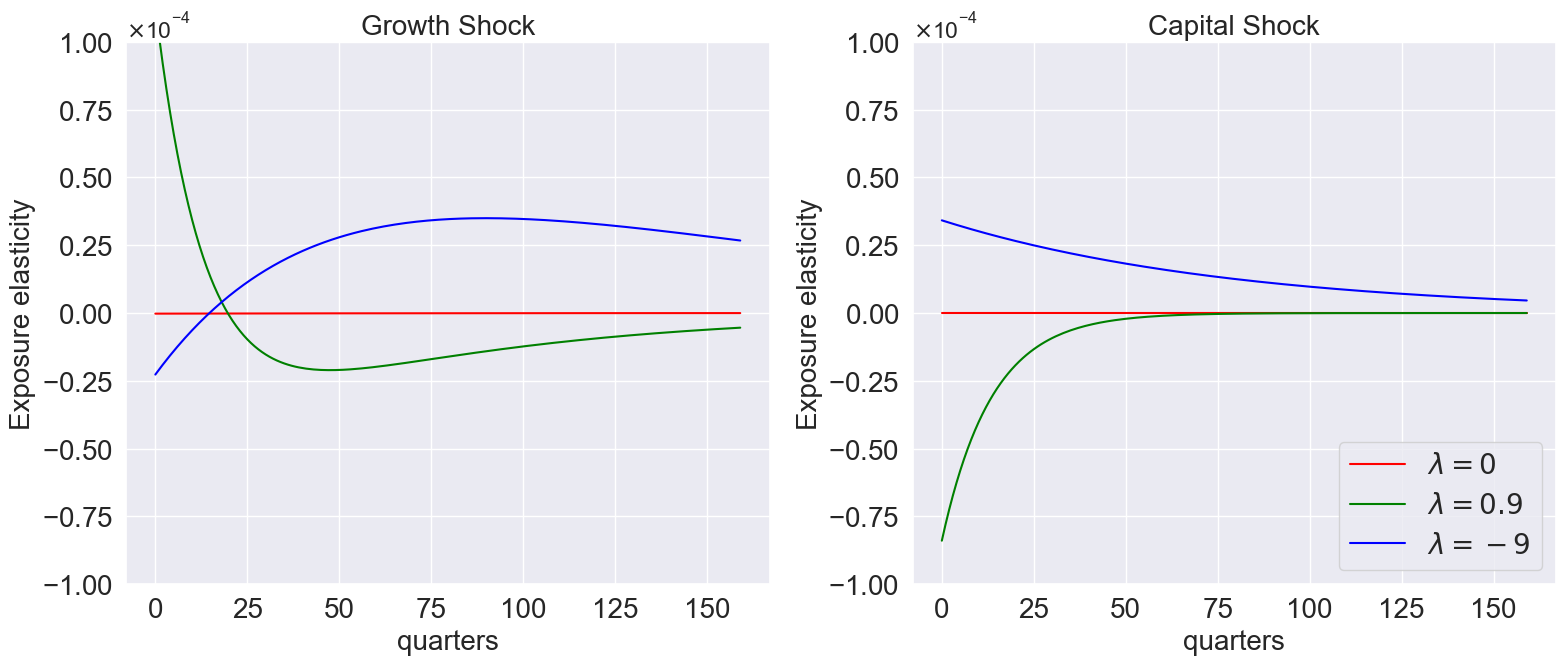

In [132]:
model_list=[models['gamma_1.001_lambda_0.0'],
        models['gamma_1.001_lambda_0.9'],
        models['gamma_1.001_lambda_-9.0']]
plot_exposure_elasticity_shocks(
    model_list,
    Mtgrowth_list = [compute_logMtM0(model) for model in model_list],
    quantile=[0.5],
    T=160,
    num_shocks=2,
    time_unit='quarters',
    ylimits=[-1e-4, 1e-4],
    labels=[r'$\lambda=0$', r'$\lambda=0.9$', r'$\lambda=-9$'],
    colors=['red','green','blue'],
    title=None,
    # save_path='/plots_external/lambda_varying.png'         # Figure 8.6
)

We can also illustrate exposure elasticities by varying over quantiles:

In [133]:
def plot_exposure_quantiles(
    model_list, 
    quantile, 
    Mtgrowth_list,
    T, 
    num_shocks, 
    time_unit='quarters', 
    ylimits=None, 
    titles=None, 
    title=None, 
    shock_names=None, 
    colors=None, 
    save_path=None
):
    """
    Plot exposure elasticity quantiles for multiple models across subplots.
    
    Parameters:
    - model_list: List of model results to plot.
    - quantile: List of quantiles to calculate.
    - T: Integer, time horizon.
    - num_shocks: Integer, number of shocks to include.
    - time_unit: String, label for x-axis time units (e.g., "quarters").
    - ylimits: List, optional y-axis limits for the subplots.
    - titles: List of titles for individual subplots.
    - title: String, optional title for the overall figure.
    - shock_names: List of strings, names for the shocks (optional, not used in this specific plot).
    - colors: List of strings, colors for the quantiles.
    - save_path: String, optional path to save the plot.
    """
    sns.set_style("darkgrid")
    num_models = len(model_list)

    # Default settings
    if titles is None:
        titles = [f'Model {i + 1}' for i in range(num_models)]
    if colors is None:
        colors = ['green', 'red', 'blue']

    # Initialize figure and axes
    fig, axes = plt.subplots(1, num_models, figsize=(8 * num_models, 7), squeeze=False)
    axes = axes.flatten()  # Flatten to ensure direct indexing works

    # Main plotting loop
    for idx, res in enumerate(model_list):
        Mtgrowth = Mtgrowth_list[idx]
        X1_tp1 = res['X1_tp1']
        X2_tp1 = res['X2_tp1']
        
        # Calculate exposure elasticity for each shock
        expo_elas_shocks = [
            [exposure_elasticity(Mtgrowth, X1_tp1, X2_tp1, T, shock=i, percentile=p) for p in quantile]
            for i in range(min(num_shocks + 1, 2))
        ]

        # Reorder shocks
        reordered_shocks = [expo_elas_shocks[1]] + [expo_elas_shocks[i] for i in range(num_shocks) if i != 1]

        # Prepare data for plotting
        index = ['T'] + [f'{q} quantile' for q in quantile]
        shock_data = [
            pd.DataFrame([np.arange(T), *[e.flatten() for e in reordered_shocks[i]]], index=index).T
            for i in range(num_shocks)
        ]

        # Plot each shock for the current model
        for i in range(num_shocks):
            for j in range(len(quantile)):
                sns.lineplot(data=shock_data[i], x='T', y=index[j + 1], ax=axes[idx], 
                             color=colors[j], label=index[j + 1])

            # Customize the subplot
            axes[idx].set_xlabel('')
            axes[idx].set_ylabel('Exposure elasticity', fontsize=20)
            axes[idx].set_title(titles[idx], fontsize=20)
            axes[idx].tick_params(axis='y', labelsize=20)
            axes[idx].tick_params(axis='x', labelsize=20)
            axes[idx].legend(fontsize=20, loc='lower right')

            # Set y-axis limits if provided
            if ylimits:
                axes[idx].set_ylim(ylimits)
            if i != 0:  # Skip the legend for the second subplot
                axes[i].legend(fontsize=20, loc='lower right')
            else:
                axes[i].legend().remove()  # Ensure no legend appears on the second plot

            # Set scientific notation for the y-axis
            axes[idx].yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
            axes[idx].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))


    # Set x-axis label for all subplots
    for ax in axes:
        ax.set_xlabel(f'{time_unit}', fontsize=20)

    # Set the main figure title, if provided
    if title:
        fig.suptitle(title, fontsize=24)

    plt.tight_layout()

    # Save and/or display the plot
    if save_path:
        plt.savefig(save_path, dpi=500)
    plt.show()

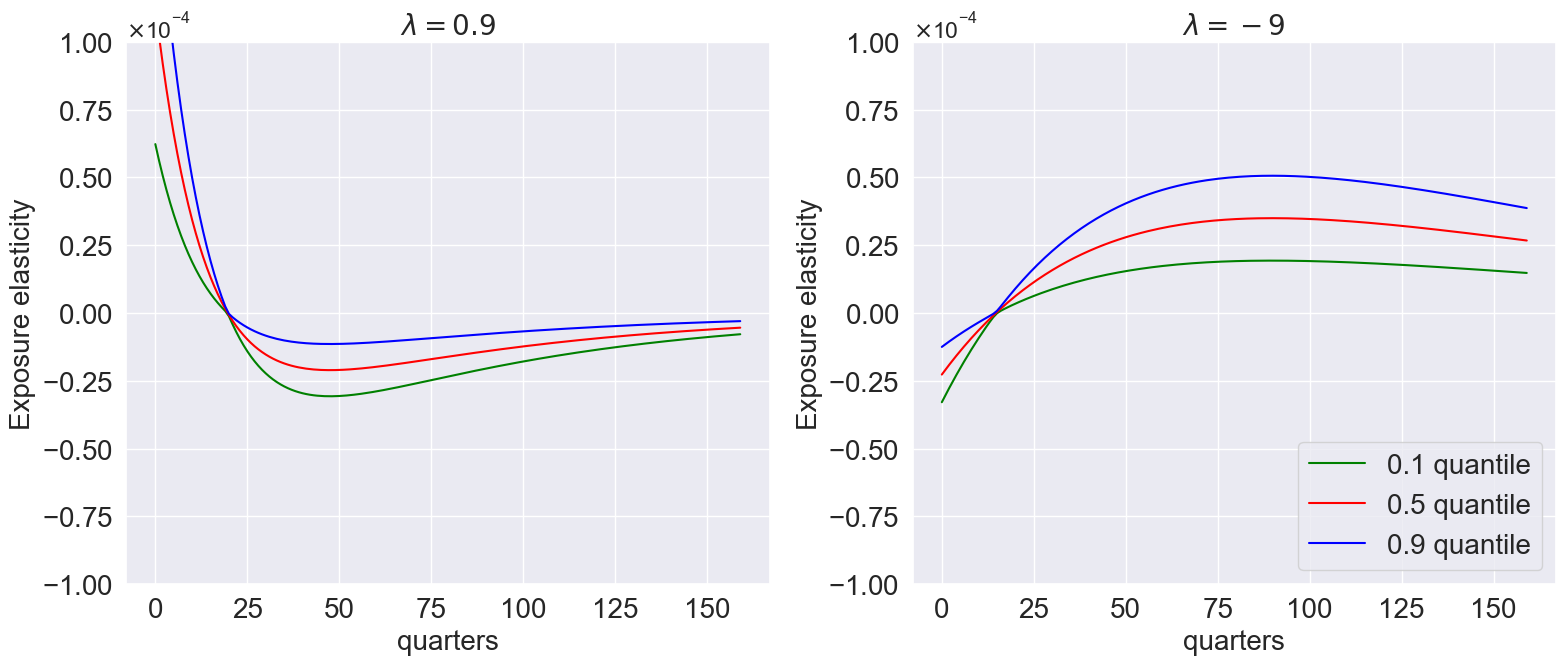

In [134]:
model_list=[
        models['gamma_1.001_lambda_0.9'],
        models['gamma_1.001_lambda_-9.0']
    ]
plot_exposure_quantiles(
    model_list,
    quantile=[0.1, 0.5, 0.9],
    Mtgrowth_list = [compute_logMtM0(model) for model in model_list],
    T=160,
    num_shocks=1,
    time_unit='quarters',
    ylimits=[-1e-4, 1e-4],
    titles=[r'$\lambda=0.9$', r'$\lambda=-9$'],
    title=None,
    # save_path='../plots/quantiles.png'      # Figure 8.7
)


Finally we can plot price elasticities:

In [136]:
def plot_price_elasticity(models, T, quantile, time_unit, title=None, ylimits=None, save_path=None):
    """
    Calculate and plot price elasticity for different models across subplots.
    
    Parameters:
    - models: List of result dictionaries to plot.
    - T: Integer, time horizon.
    - quantile: List of quantiles to calculate.
    - time_unit: String, label for x-axis time units (e.g., "quarters").
    - ylimits: Optional, list of y-axis limits for each subplot.
    - save_path: Optional, path to save the figure.
    """
    sns.set_style("darkgrid")
    num_models = len(models)

    # Initialize figure and axes for subplots
    fig, axes = plt.subplots(1, num_models, figsize=(8 * num_models, 8), squeeze=False)
    axes = axes.flatten()  # Ensure axes are flattened for easy iteration
    titles = [r'$\gamma=1$',r'$\gamma=4$',r'$\gamma=8$']

    for idx, res in enumerate(models):
        # Extract data from the current model
        X1_tp1 = res['X1_tp1']
        X2_tp1 = res['X2_tp1']
        gc_tp1 = res['gc_tp1']
        vmr_tp1 = res['vmr1_tp1'] + 0.5 * res['vmr2_tp1']
        logNtilde = res['log_N_tilde']

        # Calculate log_SDF
        β = get_parameter_value('beta', res['parameter_names'], res['args'])
        ρ = get_parameter_value('rho', res['parameter_names'], res['args'])
        log_SDF = np.log(β) - ρ * gc_tp1 + (ρ - 1) * vmr_tp1 + logNtilde

        # Calculate price elasticity for each shock
        price_elas_shock = [
            price_elasticity(gc_tp1, log_SDF, X1_tp1, X2_tp1, T, shock=1, percentile=p) for p in quantile
        ]

        # Prepare data for plotting
        index = ['T'] + [f'{q} quantile' for q in quantile]
        shock_data = pd.DataFrame(
            [np.arange(T), *[e.flatten() for e in price_elas_shock]],
            index=index
        ).T

        # Plot on the respective subplot
        ax = axes[idx]
        qt = [f'{q} quantile' for q in quantile]
        colors = ['green', 'red', 'blue']

        for j in range(len(quantile)):
            sns.lineplot(data=shock_data, x='T', y=qt[j], ax=ax, color=colors[j], label=qt[j])
        
        # Customize the subplot
        ax.set_xlabel(time_unit, fontsize=30)
        ax.set_ylabel('Price elasticity', fontsize=30)
        ax.set_title(titles[idx], fontsize=30)
        ax.tick_params(axis='y', labelsize=30)
        ax.tick_params(axis='x', labelsize=30)
        if idx == 0:
            ax.legend(fontsize=25)
        else:
            ax.legend().set_visible(False)

        if ylimits:
            ax.set_ylim(ylimits)
    # plt.suptitle('$\lambda=$'+title,fontsize=35)
    plt.tight_layout()

    # Save and/or display the plot
    if save_path:
        plt.savefig(save_path, dpi=500)
    plt.show()


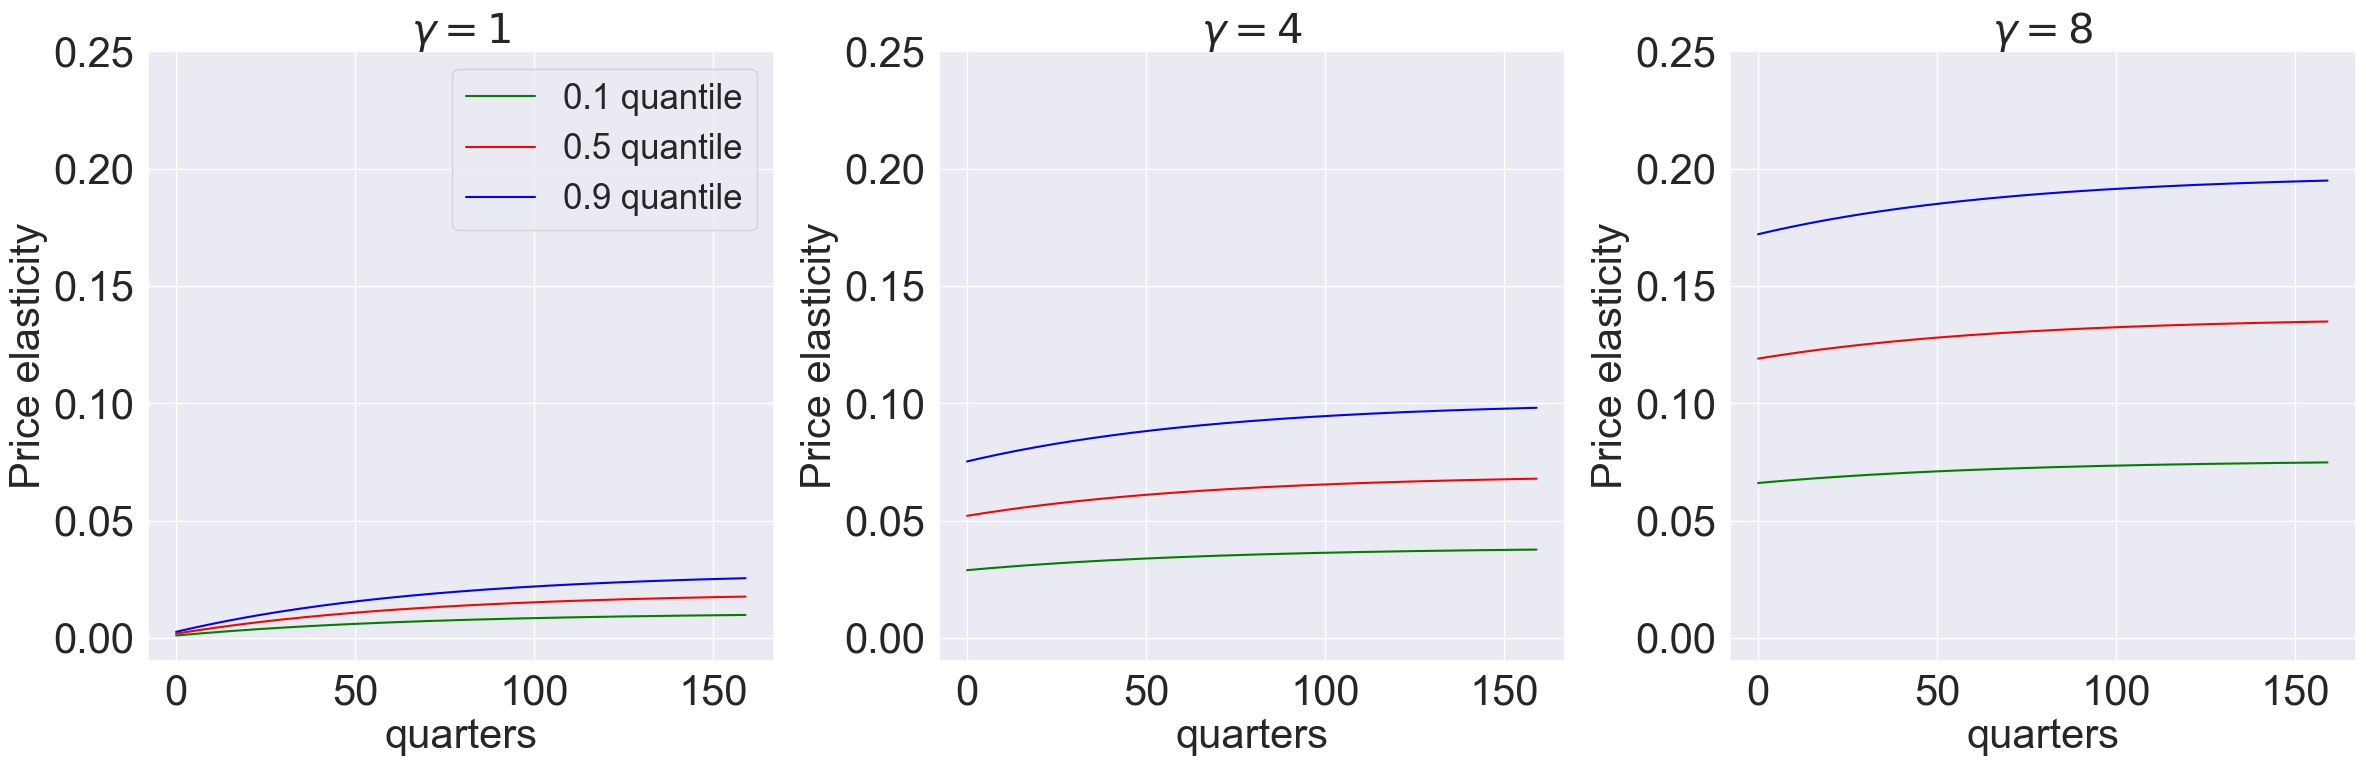

In [147]:
model_list = [models['gamma_1.001_lambda_0.0'],models['gamma_4.001_lambda_0.0'],models['gamma_8.001_lambda_0.0']]
T = 160
plot_price_elasticity(model_list,T,[0.1,0.5,0.9],'quarters','0',[-0.01,0.25]) #,r'plots/lambda0')

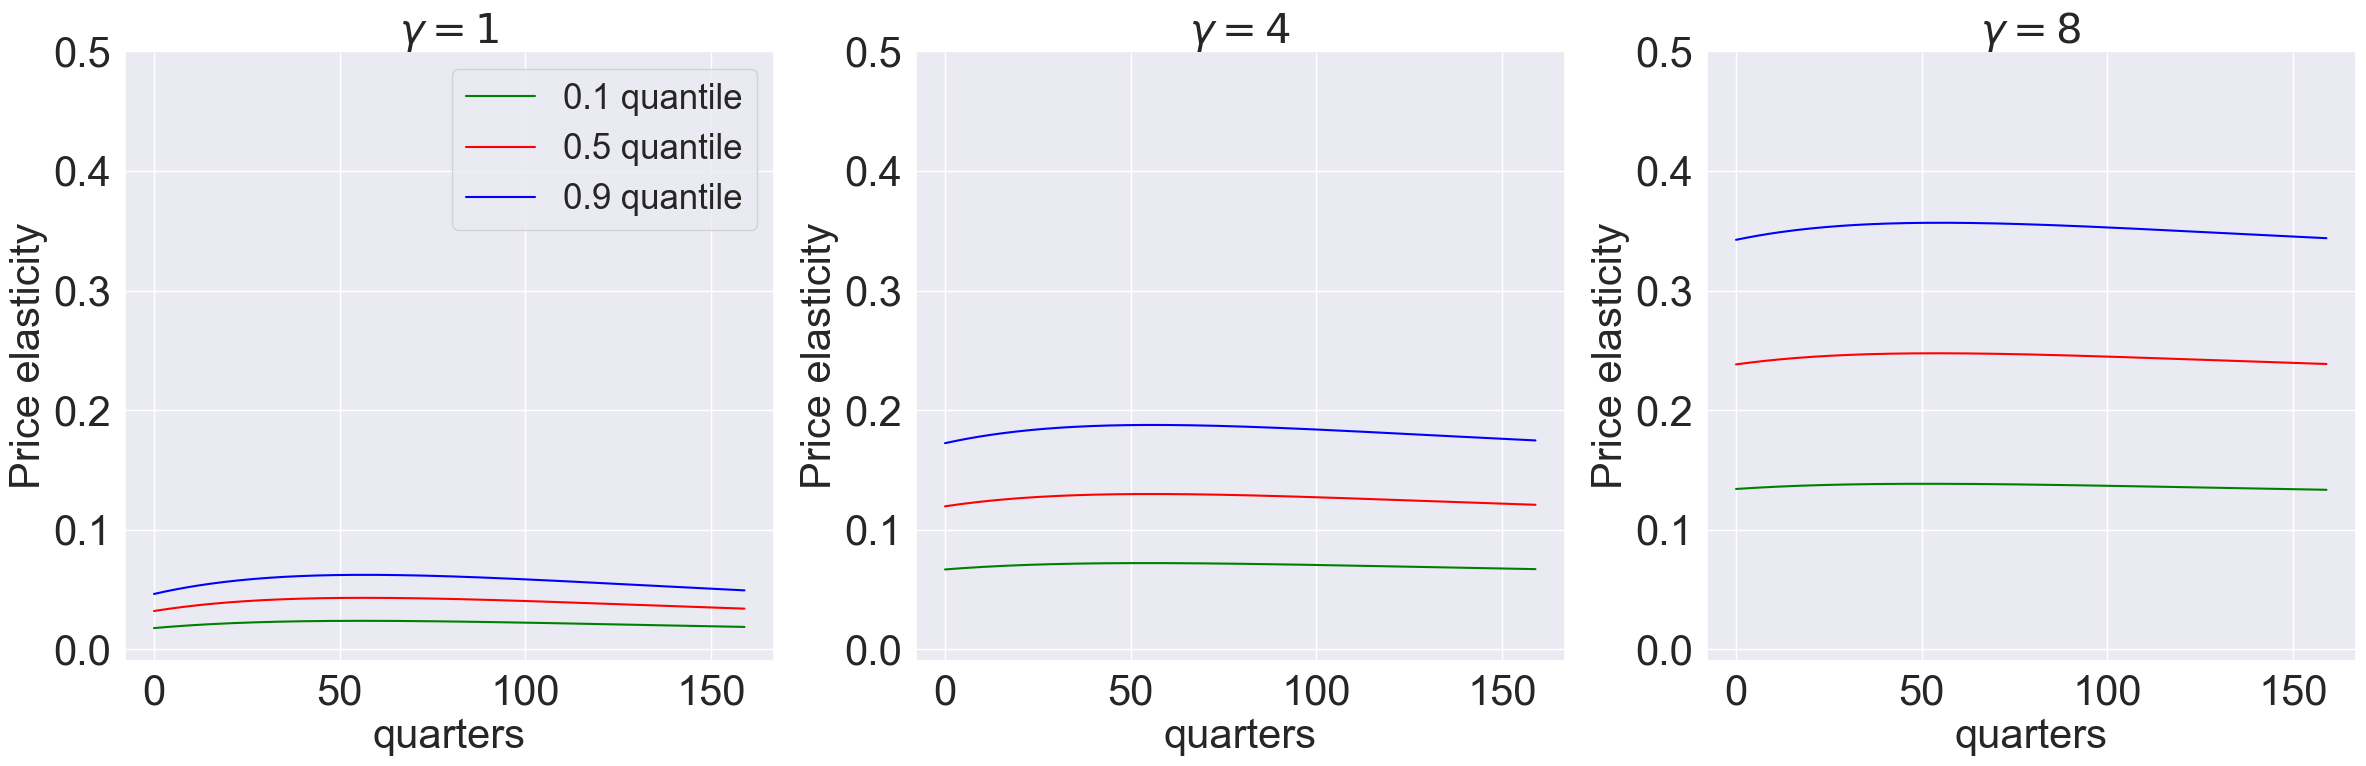

In [146]:
model_list = [models['gamma_1.001_lambda_-9.0'],models['gamma_4.001_lambda_-9.0'],models['gamma_8.001_lambda_-9.0']]
T = 160
plot_price_elasticity(model_list,T,[0.1,0.5,0.9],'quarters','-1',[-0.01,0.5]) #,r'plots/-lambda1')

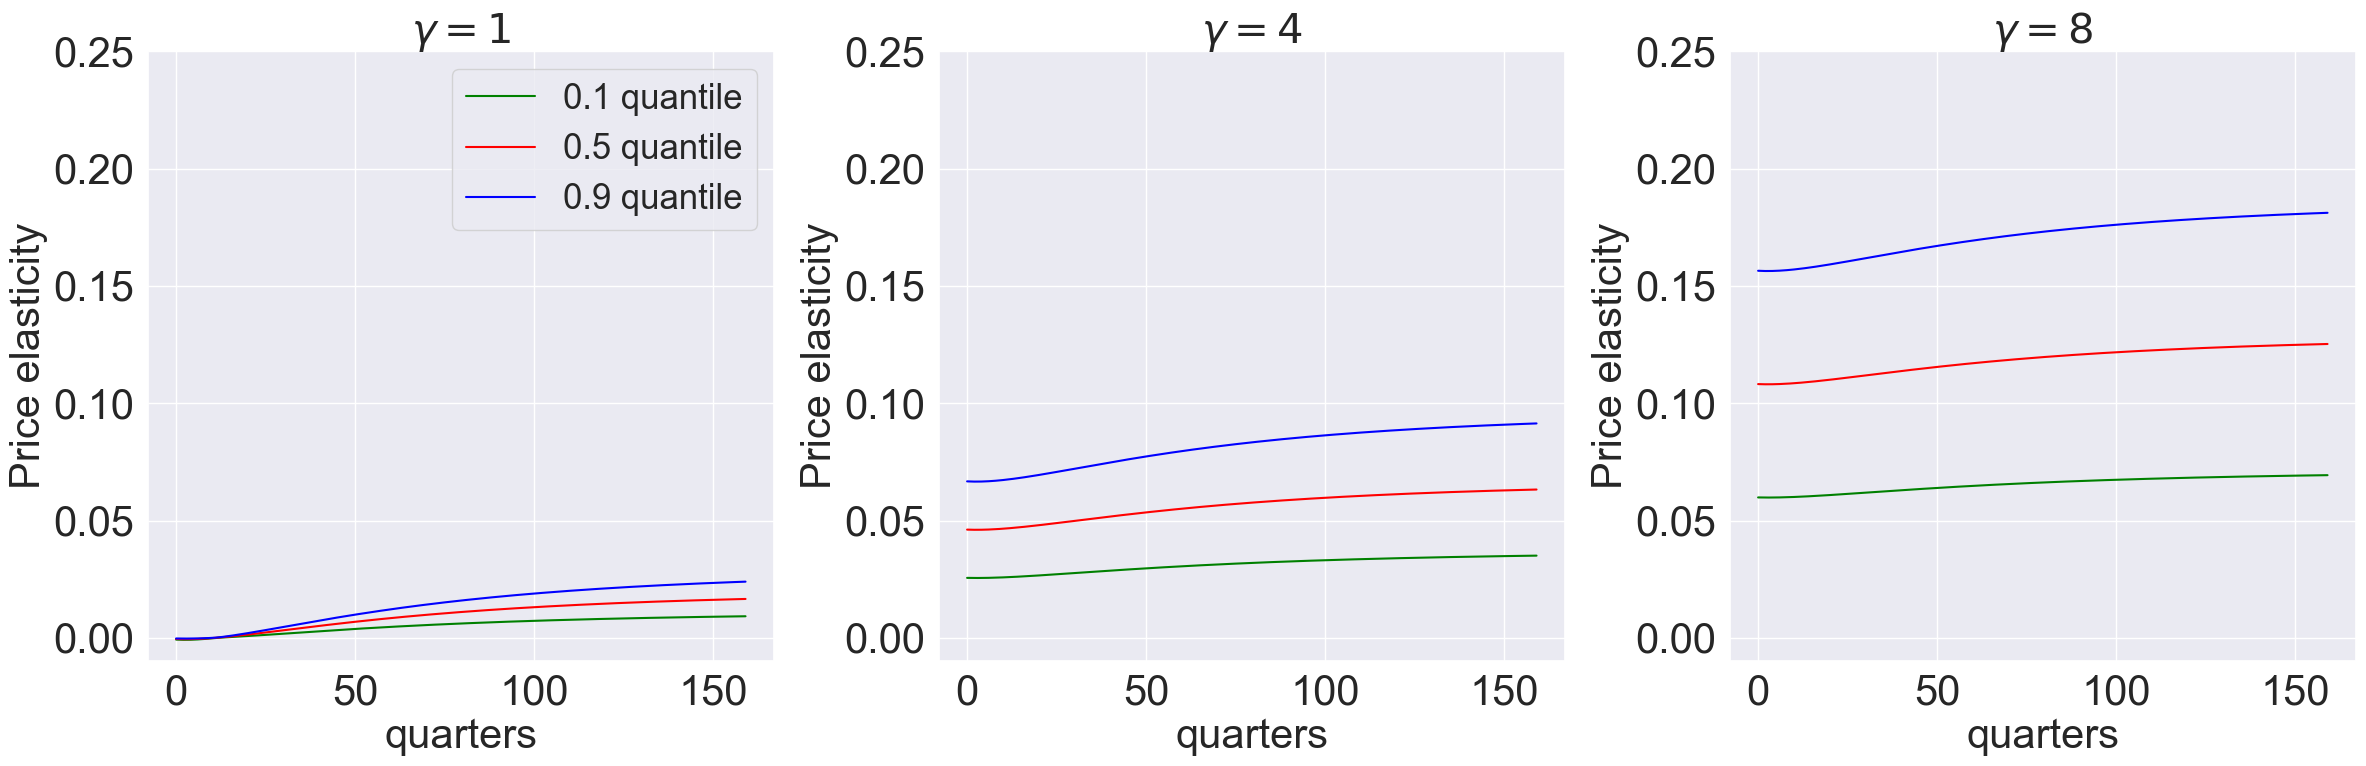

In [145]:
model_list = [models['gamma_1.001_lambda_0.9'],models['gamma_4.001_lambda_0.9'],models['gamma_8.001_lambda_0.9']]
T = 160
plot_price_elasticity(model_list,T,[0.1,0.5,0.9],'quarters','0.5',[-0.01,0.25]) #,r'plots/lambda05')

## 2.6 External Habit Model

For internal habit model, we have FOC which is 
$$MS_t = (1 - \beta) \left(\frac {1-\lambda}{D_{1,t}} \right) + {\mathbb E} \left(N_{t+1}^* \begin{bmatrix} \frac {\beta K_t\left[1 - \exp(-\nu_h)\right]}  {\exp(X_{t+1}) K_{t+1}}  & 0 & 0 \end{bmatrix} 
  MX_{t+1} \mid {\mathfrak A}_t \right)$$

For external habit, we have the FOC which is 
$$MS_t = (1 - \beta) \left( \frac {1- \lambda} {D_{1,t}} \right) $$ 


We need to change the function `compile_equations` to change the  FOC.  `compile_equations` compiles FOC and costate following

$$\begin{align*} 
Q_t {\mathbb E} \left( N_{t+1} H_{t+1} \mid {\mathfrak A}_t \right)  + P_t L_{t}  -  M_t  =    0 
\end{align*}$$
where
$$\begin{align*}
Q_t = & \hspace{.2cm}  \beta \exp\left[(1-\rho) \left( {\widehat R}_t - {\widehat V}_t \right) \right] \cr \cr
P_t = & \hspace{.2cm} (1-\beta) \exp\left[(\rho-1) \left( {\widehat V}_t - {\widehat G}_t \right) \right] \cr \cr
H_{t+1}  = & \hspace{.2cm} \begin{bmatrix} \psi_{d'}^x (D_t, X_t, W_{t+1})' &  \psi_{d'}^g (D_t, X_t, W_{t+1}) \cr \psi_{x'}^x (D_t, X_t, W_{t+1})' &  \psi_{x'}^g (D_t, X_t, W_{t+1})' \cr 
\psi_{g'}^x (D_t, X_t, W_{t+1})' & 1 \end{bmatrix} \begin{bmatrix} MX_{t+1} \cr MG_{t+1} \end{bmatrix} 
\ \cr \cr
L_t = & \hspace{.2cm} \begin{bmatrix}  \exp \left[ (1-\rho) \left({\widehat C}_t - {\widehat G}_t \right) \right]   
 \begin{bmatrix}  \kappa_d(D_t,X_t)  \cr \kappa_x(D_t, X_t) \cr 1 \end{bmatrix}  \end{bmatrix} \cr
M_t = & \hspace{.2cm} \begin{bmatrix} 0 \cr MX_t \cr MG_t  \end{bmatrix} +  \begin{bmatrix} \phi_{d'}(D_t, X_t)' \cr \phi_{x'}(D_t,X_t)' \cr 0 \end{bmatrix} MS_t .
\end{align*}$$

In our case, the $\psi_{d'}^x (D_t, X_t, W_{t+1})$ should be $ 3 \times 2$ matrix as we have state variable $[Z_{1,t}, Z_{2,t}, X_{1,t}]$ and two controls $[\frac{I_{h,t}}{K_t}, \frac{I_{k,t}}{K_t}]$. To implement external habit model, we need to the derivetive of $X_{1,t}$ process w.r.t $\frac{I_{h,t}}{K_t}$ equal to zero. 

Fortunately, we implemented this exercise and make it very easy to use for the homework. In the equation  `uncertainty_expansion`, when you turn on the option `ExternalHabit`= True  and change nothing else from the internal habit model, the code will solve the external habit model. Here is the example:

In [153]:
gamma_values  = [1.001, 4.001,  8.001] 
lambda_values = [-9.0,-8.0, -7.0, -6.0, -5.0, -4.0,-3.0,-2.0 ,-1.0,0.0, 0.1, 0.2, 0.3, 0.4,0.5,0.6, 0.7, 0.8, 0.9] 

initial_guess_baseline = initial_guess.copy()   # whatever you used before

preloadpath = None   # optional: external warm start (e.g. from a very easy case)

for gamma_i in gamma_values:
    # update gamma once per outer loop
    args = change_parameter_value('gamma', parameter_names, args, gamma_i)
    print(f"gamma: {gamma_i}")

    # store the last solution’s steady state for this gamma
    prev_ss = None

    for llambda_i in lambda_values:
        llambda_i = round(llambda_i, 2)
        args = change_parameter_value('llambda', parameter_names, args, llambda_i)
        print(f"lambda: {llambda_i}")

        savepath = f'output_external/res_gamma_{gamma_i}_lambda_{llambda_i}.pkl'

        # 0. If this parameter combo was already solved before, just load & move on
        if os.path.exists(savepath):
            with open(savepath, 'rb') as f:
                res = pickle.load(f)
            prev_ss = res['ss']
            print("  -> loaded existing solution from disk")
            continue

        # 1. Choose initial_guess:
        if prev_ss is not None:
            # use solution from previous λ for this γ
            initial_guess = np.concatenate([np.array([-3.40379947]), prev_ss])
        elif preloadpath is not None and os.path.exists(preloadpath):
            # optional: use some external “easy” case as a starting point
            with open(preloadpath, 'rb') as f:
                preload = pickle.load(f)
            initial_guess = np.concatenate([np.array([-3.40379947]), preload['ss']])
        else:
            # fall back to your original global guess
            initial_guess = initial_guess_baseline

        # 2. Solve at (gamma_i, llambda_i)
        res = uncertain_expansion(
            control_variables, state_variables, shock_variables,
            variables, variables_tp1,
            kappa, capital_growth, state_equations, static_constraints,
            initial_guess, parameter_names,
            args, approach='1', init_util=init_util,
            iter_tol=iter_tol, max_iter=max_iter,
            savepath=savepath,   # still writes to disk inside
            ExternalHabit=True
        )

        # 3. Store this steady state to warm-start the next λ
        prev_ss = res['ss']

        # and optionally make this the preload for future runs / sessions
        preloadpath = savepath


gamma: 1.001
lambda: -9.0
  -> loaded existing solution from disk
lambda: -8.0
  -> loaded existing solution from disk
lambda: -7.0
  -> loaded existing solution from disk
lambda: -6.0
  -> loaded existing solution from disk
lambda: -5.0
  -> loaded existing solution from disk
lambda: -4.0
  -> loaded existing solution from disk
lambda: -3.0
  -> loaded existing solution from disk
lambda: -2.0
  -> loaded existing solution from disk
lambda: -1.0
  -> loaded existing solution from disk
lambda: 0.0
  -> loaded existing solution from disk
lambda: 0.1
  -> loaded existing solution from disk
lambda: 0.2
  -> loaded existing solution from disk
lambda: 0.3
  -> loaded existing solution from disk
lambda: 0.4
  -> loaded existing solution from disk
lambda: 0.5
  -> loaded existing solution from disk
lambda: 0.6
  -> loaded existing solution from disk
lambda: 0.7
  -> loaded existing solution from disk
lambda: 0.8
  -> loaded existing solution from disk
lambda: 0.9
  -> loaded existing solution 

In [154]:
models = {} 
gamma_values = [1.001, 4.001,  8.001] 
lambda_values = [-9.0,   0.0,  0.9]
for gamma_i in gamma_values:
    for llambda_i in lambda_values:
        llambda_i = round(llambda_i,2)
        save_path = 'output_external/res_gamma_{}_lambda_{}.pkl'.format(gamma_i, llambda_i)
        try:
            with open(save_path, 'rb') as f:
                # models = pickle.load(save_path)
                model_key = f"gamma_{gamma_i}_lambda_{llambda_i}"
                models[model_key] = pickle.load(f)
        except FileNotFoundError:
            print(f"File not found: {save_path}")

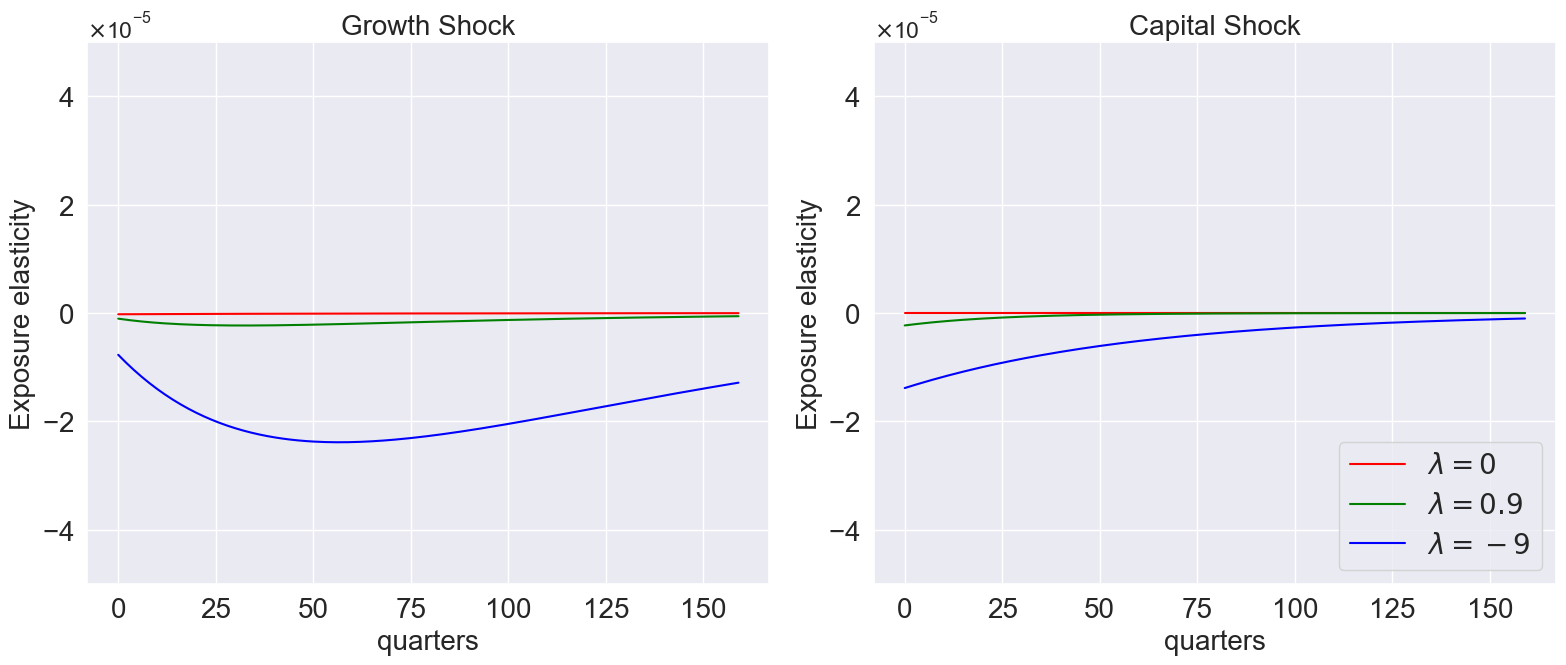

In [150]:
model_list=[models['gamma_1.001_lambda_0.0'],
        models['gamma_1.001_lambda_0.9'],
        models['gamma_1.001_lambda_-9.0']]
plot_exposure_elasticity_shocks(
    model_list,
    Mtgrowth_list = [compute_logMtM0(model) for model in model_list],
    quantile=[0.5],
    T=160,
    num_shocks=2,
    time_unit='quarters',
    ylimits=[-5e-5, 5e-5],
    labels=[r'$\lambda=0$', r'$\lambda=0.9$', r'$\lambda=-9$'],
    colors=['red','green','blue'],
    title=None,
    # save_path='/plots_external/lambda_varying.png'         # Figure 8.6
)

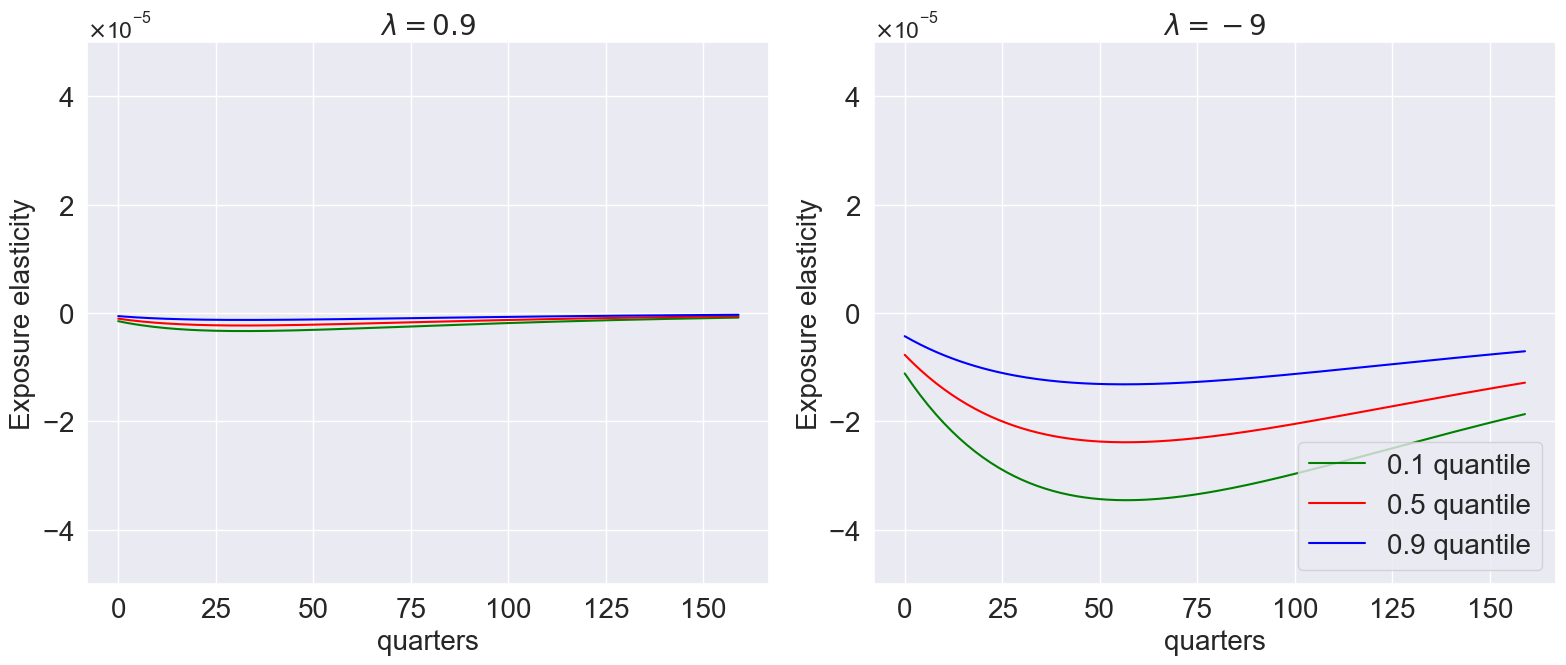

In [151]:
model_list=[
        models['gamma_1.001_lambda_0.9'],
        models['gamma_1.001_lambda_-9.0']
    ]
plot_exposure_quantiles(
    model_list,
    quantile=[0.1, 0.5, 0.9],
    Mtgrowth_list = [compute_logMtM0(model) for model in model_list],
    T=160,
    num_shocks=1,
    time_unit='quarters',
    ylimits=[-5e-5, 5e-5],
    titles=[r'$\lambda=0.9$', r'$\lambda=-9$'],
    title=None,
    # save_path='/plots_external/quantiles.png'      # Figure 8.7
)

<br>
<br>
<br>

# 3 Outputs

## 3.1 List of Outputs <a class="anchor" id="s3-1"></a>

We now examine the contents of `ModelSol`, which contains the attributes listed below. Each approximation is stored in a class `LinQuadVar`, which contains the coefficients for $X_{1,t}, X_{2,t}, X_{1,t}'X_{1,t}, W_{t+\epsilon}, W_{t+\epsilon}'W_{t+\epsilon}, X_{1,t}'W_{t+\epsilon}$ and the constant.


```{list-table} Outputs
:header-rows: 1
* - Input
  - Type
  - Description
* - `JXn_t`
  - *LinQuadVar*
  - Approximation of jump and state variables at time $t$. Replace `n` with `0,1,2` to get the zeroth, first and second-order contribution. Omit `n` to get the full approximation. The variables are indexed in the order specified in Section 2. 
* - `Jn_t`
  - *LinQuadVar*
  - Same as `JXn_t` but limited to jump variables.
* - `Xn_tp1`
  - *LinQuadVar*
  - Same as `JXn_t` but limited to state variables.
* - `JXn_t_tilde`
  - *LinQuadVar*
  - Same as `JXn_t` but using distorted measure. This variation is also available for `Jn_t` and `Xn_tp1`.
* - `util_sol`
  - *dict*
  - Dictionary containing solutions of the continuation values, including $\mu^0, \Upsilon_0^2, \Upsilon_1^2,$ and $\Upsilon_2^2$ etc.
* - `vmrn_tp1`
  - *LinQuadVar*
  - Approximation of continuation values $\widehat{V}^1_{t+\epsilon}-\widehat{R}^1_t$ . Replace `n` with `0,1,2` to get the zeroth, first and second-order contribution. Omit `n` to get the full approximation. 
* - `gcn_tp1`
  - *LinQuadVar*
  - Approximation of consumption growth $\widehat{C}_{t+\epsilon}-\widehat{C}_t$ . Replace `n` with `0,1,2` to get the zeroth, first and second-order contribution. Omit `n` to get the full approximation. 
* - `ss`
  - *dict*
  - Steady states for state and jump variables
* - `log_N_tilde`
  - *LinQuadVar*
  - Approximation for the log change of measure
```

For example, we can obtain the coefficients for the first-order contribution of $\log{C_t/K_t}$ in the following way, noting that `cmk_t` was listed as the first jump variable when we specified the equilibrum conditions.


In [71]:
## Log consumption over capital approximation results, shown in the LinQuadVar coefficients form
ModelSol['JX1_t'][0].coeffs

{'x': array([[ 0.        ,  0.10420544, -0.        , -0.52822907]]),
 'c': array([[-0.0191216]])}

We can also display the full second-order approximation of $\log{C_t/K_t}$ using the `disp` function, which renders a `LinQuadVar` object in LATEX form.

In [72]:
## Log consumption over capital approximation results, shown in the Latex analytical form
disp(ModelSol['JX_t'][0],'\\log\\frac{C_t}{K_t}') 

<IPython.core.display.Math object>

Another example:

In [73]:
## Log capital growth process second order approximation results
disp(ModelSol['X2_tp1'][0],'\\log\\frac{K_{t+\epsilon}^2}{K_t^2}') 

<IPython.core.display.Math object>

In [74]:
## Log consumption over capital approximation results, shown in the LinQuadVar coefficients form
ModelSol['JX1_t'][0].coeffs

{'x': array([[ 0.        ,  0.10420544, -0.        , -0.52822907]]),
 'c': array([[-0.0191216]])}

We can also display the full second-order approximation of $\log{C_t/K_t}$ using the `disp` function, which renders a `LinQuadVar` object in LATEX form.

In [75]:
ModelSol['JX_t'][0]["x"]

array([[ 0.        ,  0.10821926, -0.0063016 , -0.52504922]])

In [78]:
## Log consumption over capital approximation results, shown in the Latex analytical form
disp_new(ModelSol['JX_t'][0],'\\log\\frac{C_t}{K_t}') 

<IPython.core.display.Math object>

Another example:

In [79]:
## Log capital growth process second order approximation results
disp_new(ModelSol['X2_tp1'][0],'\\log\\frac{K_{t+\epsilon}^2}{K_t^2}') 

<IPython.core.display.Math object>

<br>

## 3.2 Simulate Variables <a class="anchor" id="s3-3"></a>
Given a series of shock processes, we can simulate the path of our state and jump variables using the `ModelSolution.simulate` method. Here, we simulate 400 periods of i.i.d standard multivariate normal shocks.

In [18]:
n_J, n_X, n_W = ModelSol['var_shape']
Ws = np.random.multivariate_normal(np.zeros(n_W),np.eye(n_W),size = 400)
JX_sim = ModelSol.simulate(Ws)

<br>
<br>

# 4 Using `LinQuadVar` in Computation <a class="anchor" id="s2"></a>

In the previous section, we saw how to use `uncertain_expansion` to approximate variables and store their coefficients as `LinQuadVar` objects. In this section, we explore how to manipulate `LinQuadVar` objects for different uses.

To aid our examples, we first extract the steady states for the state evolution processes from the previous model solution:

See [src/lin_quad.py](https://github.com/lphansen/RiskUncertaintyValue/blob/main/src/lin_quad.py) for source code of `LinQuadVar` definition.

In [29]:
ModelSol['ss'][[0,1,2]]

array([-4.33215389,  0.0259344 ,  0.02039568])

In [53]:
n_J, n_X, n_W = ModelSol['var_shape']
print(n_J, n_X, n_W)
X0_tp1 = LinQuadVar({'c':np.array([[ModelSol['ss'][0]],[ModelSol['ss'][1]],[ModelSol['ss'][2]], [ModelSol["ss"][3]]])}, shape = (n_X, n_X, n_W))

6 4 3


## 4.1 `LinQuadVar` Operations <a class="anchor" id="s4-1"></a>
We can sum multiple LinQuads together in two different ways. Here we demonstrate this with an example by summing the zeroth, first and second order contributions of our approximation for capital growth. 

In [31]:
gk_tp1 = X0_tp1[0] + ModelSol['X1_tp1'][0]  + 0.5 * ModelSol['X2_tp1'][0] 
disp(gk_tp1,'\\log\\frac{K_{t+\epsilon}}{K_t}') 

<IPython.core.display.Math object>

In the next example, we sum together the contributions for both capital growth and technology:

In [32]:
lq_sum([X0_tp1, ModelSol['X1_tp1'], 0.5 * ModelSol['X2_tp1']]).coeffs

{'xx': array([[-0.        , -0.        ,  0.        ,  0.        ,  0.        , -0.00022514,  0.        ,  0.00001292,  0.        ,  0.        , -0.        ,  0.        ,  0.        ,  0.00001093,
          0.        , -0.00003523],
        [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.097     ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        , -0.        ,  0.        , -0.        ,  0.00025426, -0.        ,  0.00000844, -0.        , -0.        ,  0.        , -0.        ,  0.        ,  0.00001072,
         -0.        ,  0.00005381]]),
 'c': array([[-4.33102269],
        [ 0.0259344 ],
        [-0.07112813],
        [-

## 4.2 `LinQuadVar` Split and Concat <a class="anchor" id="s4-2"></a>
`split` breaks multiple dimensional LinQuad into one-dimensional LinQuads, while `concat` does the inverse.

In [34]:
gk_tp1, Z_tp1, Y_tp1, X_tp1 = ModelSol['X1_tp1'].split()
concat([gk_tp1, Z_tp1, Y_tp1])

## 4.3 Evaluate a `LinQuadVar` <a class="anchor" id="s4-3"></a>
We can evaluate a LinQuad at specific state $(X_{t},W_{t+\epsilon})$ in time. As an example, we evaluate all 5 variables under steady state with a multivariate random normal shock.

In [47]:
x1 = np.zeros([n_X ,1])
x2 = np.zeros([n_X ,1])
x3 = np.zeros([n_X, 1])
w = np.random.multivariate_normal(np.zeros(n_W),np.eye(n_W),size = 1).T
ModelSol['JX_tp1'](*(x1,x2,w))

array([[ -4.40157174],
       [  0.02420615],
       [  0.02040907],
       [ -0.0002646 ],
       [ -0.00021192],
       [  0.99999632],
       [  0.02218119],
       [  0.01258757],
       [-12.16998153],
       [ -0.01876417]])

## 4.4 Next period expression for `LinQuadVar` <a class="anchor" id="s4-4"></a>
`ModelSol` allows us to express a jump variable $J_t$ as a function of $t$ state and shock variables. Suppose we would like to compute its next period expression $J_{t+\epsilon}$ with shocks. The function `next_period` expresses $J_{t+\epsilon}$ in terms of $t$ state variables and $t+\epsilon$ shock variables. For example, we can express the $t+\epsilon$ expression for the first-order contribution to consumption over capital as:

In [48]:
ModelSol["X1_tp1"].coeffs

{'x': array([[-0.        ,  0.03710412, -0.        ,  0.00006824],
        [-0.        ,  0.944     , -0.        , -0.        ],
        [-0.        , -0.        ,  0.806     , -0.        ],
        [ 0.        , -0.0366626 ,  0.        , -0.10516689]]),
 'w': array([[ 0.00799924,  0.00347793, -0.        ],
        [-0.        ,  0.04956051, -0.        ],
        [-0.        , -0.        ,  0.42784065],
        [-0.00799924, -0.00347793, -0.        ]]),
 'c': array([[ 0.00111162],
        [ 0.        ],
        [ 0.        ],
        [-0.0012811 ]])}

In [49]:
cmk1_tp1 = next_period(ModelSol['J1_t'][0], ModelSol['X1_tp1'])
disp(cmk1_tp1, '\\log\\frac{C_{t+\epsilon}^1}{K_{t+\epsilon}^1}') 

<IPython.core.display.Math object>

In [50]:
cmk2_tp1 = next_period(ModelSol['J2_t'][0], ModelSol['X1_tp1'], ModelSol['X2_tp1'])
disp(cmk2_tp1, '\\log\\frac{C_{t+\epsilon}^2}{K_{t+\epsilon}^2}') 

<IPython.core.display.Math object>

## 4.6 Compute the Expectation of time $t+\epsilon$ `LinQuadVar` <a class="anchor" id="s4-6"></a>

Suppose the distribution of shocks has a constant mean and variance (not state dependent). Then, we can use the `E` function to compute the expectation of a time $t+\epsilon$ `LinQuadVar` as follows:


In [51]:
E_w = ModelSol['util_sol']['μ_0']
cov_w = np.eye(n_W)
E_ww = cal_E_ww(E_w, cov_w)
E_cmk2_tp1 = E(cmk2_tp1, E_w, E_ww)
disp(E_cmk2_tp1, '\mathbb{E}[\\log\\frac{C_{t+\epsilon}^2}{K_{t+\epsilon}^2}|\mathfrak{F_t}]')

<IPython.core.display.Math object>

Suppose the distribution of shock has a state-dependent mean and variance (implied by $\tilde{N}_{t+\epsilon}$ shown in the notes), we can use `E_N_tp1` and `N_tilde_measure` to compute the expectation of time $t+\epsilon$ `LinQuadVar`.

In [52]:
N_cm = N_tilde_measure(ModelSol['util_sol']['log_N_tilde'],(1,n_X,n_W))
E_cmk2_tp1_tilde = E_N_tp1(cmk2_tp1, N_cm)
disp(E_cmk2_tp1_tilde, '\mathbb{\\tilde{E}}[\\log\\frac{C_{t+\epsilon}^2}{K_{t+\epsilon}^2}|\mathfrak{F_t}]')

<IPython.core.display.Math object>